<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/blackhole.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 413ms/step - accuracy: 0.6513 - loss: 0.6282 - val_accuracy: 0.9700 - val_loss: 0.1712
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 175ms/step - accuracy: 0.9907 - loss: 0.0692 - val_accuracy: 1.0000 - val_loss: 2.6921e-04
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 239ms/step - accuracy: 1.0000 - loss: 1.1654e-04 - val_accuracy: 1.0000 - val_loss: 2.6725e-05
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 175ms/step - accuracy: 1.0000 - loss: 2.8996e-05 - val_accuracy: 1.0000 - val_loss: 1.9868e-05
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 233ms/step - accuracy: 1.0000 - loss: 2.2180e-05 - val_accuracy: 1.0000 - val_loss: 1.7217e-05
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step - accuracy: 1.0000 - loss: 1.9182e-05 - val_accuracy: 1.0000 - val_loss: 1.6068e-05
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - accuracy: 1.0000 - loss: 1.7598e-05 - val_accuracy: 1.0000 - val_loss: 1.5037e-05
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 210ms/step - accu

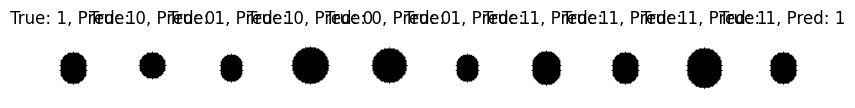

In [ ]:
# Importing necessary libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Generate synthetic image data (replace with real black hole image data from EHT)
# For simplicity, we'll create black and white images of black holes with different "shadows"
n_samples = 1000
image_size = 64  # 64x64 pixels

def generate_black_hole_image(label, image_size):
    """
    Generate a synthetic black hole image with different types of shadows.
    label: 0 for Schwarzschild, 1 for Kerr black hole.
    """
    image = np.ones((image_size, image_size))  # Start with a white image
    center = (image_size // 2, image_size // 2)
    radius = np.random.randint(10, 20)

    if label == 0:  # Schwarzschild black hole (symmetric shadow)
        rr, cc = np.ogrid[:image_size, :image_size]
        mask = (rr - center[0])**2 + (cc - center[1])**2 <= radius**2
        image[mask] = 0  # Black hole shadow

    elif label == 1:  # Kerr black hole (asymmetric shadow due to spin)
        rr, cc = np.ogrid[:image_size, :image_size]
        mask = ((rr - center[0])**2 + (cc - center[1])**2 <= radius**2) | \
               ((rr - center[0] - 5)**2 + (cc - center[1])**2 <= radius**2)
        image[mask] = 0  # Black hole shadow with an offset for asymmetry

    return image

# Create dataset
images = []
labels = []
for i in range(n_samples):
    label = np.random.choice([0, 1])  # Randomly assign a class
    img = generate_black_hole_image(label, image_size)
    images.append(img)
    labels.append(label)

images = np.array(images)
labels = np.array(labels)

# Reshape images for CNN input
images = images.reshape(-1, image_size, image_size, 1)  # 1 channel (grayscale)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

# Build a CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(image_size, image_size, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(2, activation='softmax')  # Two classes: Schwarzschild or Kerr
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print("\nTest accuracy:", test_acc)

# Predictions on the test set
y_pred = np.argmax(model.predict(X_test), axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Plot some example images with their predicted labels
def plot_images(images, labels, preds, n=10):
    plt.figure(figsize=(10, 10))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i].reshape(image_size, image_size), cmap='gray')
        plt.title(f"True: {labels[i]}, Pred: {preds[i]}")
        plt.axis('off')
    plt.show()

# Show some results
plot_images(X_test[:10], y_test[:10], y_pred[:10])


In [ ]:
!pip install astropy tensorflow numpy matplotlib

In [ ]:
# Import necessary libraries
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

# Function to read and preprocess FITS image data
def read_fits_image(fits_file):
    """
    Read a FITS file and return the image data.
    """
    hdul = fits.open(fits_file)  # Open the FITS file
    image_data = hdul[0].data  # Get the image data from the primary HDU
    hdul.close()  # Close the FITS file
    return image_data

# Path to your FITS file(s) - you can replace this with the actual path to EHT data
fits_file_schwarzschild = 'path_to_schwarzschild_black_hole_image.fits'
fits_file_kerr = 'path_to_kerr_black_hole_image.fits'

# Read the FITS files
image_schwarzschild = read_fits_image(fits_file_schwarzschild)
image_kerr = read_fits_image(fits_file_kerr)

# Normalize the image data
image_schwarzschild = (image_schwarzschild - np.min(image_schwarzschild)) / (np.max(image_schwarzschild) - np.min(image_schwarzschild))
image_kerr = (image_kerr - np.min(image_kerr)) / (np.max(image_kerr) - np.min(image_kerr))

# Visualize the images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_schwarzschild, cmap='gray')
plt.title('Schwarzschild Black Hole')

plt.subplot(1, 2, 2)
plt.imshow(image_kerr, cmap='gray')
plt.title('Kerr Black Hole')
plt.show()

# Creating a synthetic dataset by repeating and stacking images
n_samples = 1000  # You can use more or less depending on available data

# Generate labels: 0 for Schwarzschild, 1 for Kerr
labels = np.array([0] * (n_samples // 2) + [1] * (n_samples // 2))

# Stack the images (assume each black hole type has n_samples/2 images)
images = np.array([image_schwarzschild] * (n_samples // 2) + [image_kerr] * (n_samples // 2))

# Reshape the images for CNN input
image_size = image_schwarzschild.shape[0]  # Assuming square images
images = images.reshape(-1, image_size, image_size, 1)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

# Build the CNN model (similar to the synthetic example)
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(image_size, image_size, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(2, activation='softmax')  # Two classes: Schwarzschild or Kerr
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print("\nTest accuracy:", test_acc)

# Predictions on the test set
y_pred = np.argmax(model.predict(X_test), axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Plot some example results
def plot_images(images, labels, preds, n=10):
    plt.figure(figsize=(10, 10))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i].reshape(image_size, image_size), cmap='gray')
        plt.title(f"True: {labels[i]}, Pred: {preds[i]}")
        plt.axis('off')
    plt.show()

# Show some results
plot_images(X_test[:10], y_test[:10], y_pred[:10])


FileNotFoundError: [Errno 2] No such file or directory: 'path_to_schwarzschild_black_hole_image.fits'